# Day 09. Exercise 00
# Regularization

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
import sklearn
import joblib 
import warnings
from sklearn.exceptions import ConvergenceWarning

In [2]:
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

In [3]:
print(f'Версия slkearn: {sklearn.__version__}')
print(f'Версия pandas: {pd.__version__}')

Версия slkearn: 0.23.1
Версия pandas: 1.1.5


## 1. Preprocessing

1. Read the file `dayofweek.csv` that you used in the previous day to a dataframe.
2. Using `train_test_split` with parameters `test_size=0.2`, `random_state=21` get `X_train`, `y_train`, `X_test`, `y_test`. Use the additional parameter `stratify`.

In [4]:
df = pd.read_csv('../data/dayofweek.csv')
df.head(1)

,numTrials,hour,dayofweek,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,uid_user_15,uid_user_16,uid_user_17,uid_user_18,uid_user_19,uid_user_2,uid_user_20,uid_user_21,uid_user_22,uid_user_23,uid_user_24,uid_user_25,uid_user_26,uid_user_27,uid_user_28,uid_user_29,uid_user_3,uid_user_30,uid_user_31,uid_user_4,uid_user_6,uid_user_7,uid_user_8,labname_code_rvw,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,-0.788667,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [5]:
RANDOM_STATE = 21

In [6]:
X = df.drop(columns=['dayofweek'])
y = df['dayofweek']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

In [7]:
print(f'Размерность X_train: {X_train.shape}')
print(f'Размерность X_test: {X_test.shape}')

Размерность X_train: (1348, 43)
Размерность X_test: (338, 43)


In [8]:
print(f'Распределение таргета в обучающей выборке: {y_train.value_counts(dropna=False, normalize=True)}')
print(f'Распределение таргета в тестовой выборке: {y_test.value_counts(dropna=False, normalize=True)}')

Распределение таргета в обучающей выборке: 3    0.234421
6    0.211424
1    0.162463
5    0.160979
2    0.088279
0    0.080861
4    0.061573
Name: dayofweek, dtype: float64
Распределение таргета в тестовой выборке: 3    0.236686
6    0.210059
1    0.162722
5    0.159763
2    0.088757
0    0.079882
4    0.062130
Name: dayofweek, dtype: float64


## 2. Logreg regularization

### a. Default regularization

1. Train a baseline model with the only parameters `random_state=21`, `fit_intercept=False`.
2. Use stratified K-fold cross-validation with `10` splits to evaluate the accuracy of the model


The result of the code where you trained and evaluated the baseline model should be exactly like this (use `%%time` to get the info about how long it took to run the cell):

```
train -  0.62902   |   valid -  0.59259
train -  0.64633   |   valid -  0.62963
train -  0.63479   |   valid -  0.56296
train -  0.65622   |   valid -  0.61481
train -  0.63397   |   valid -  0.57778
train -  0.64056   |   valid -  0.59259
train -  0.64138   |   valid -  0.65926
train -  0.65952   |   valid -  0.56296
train -  0.64333   |   valid -  0.59701
train -  0.63674   |   valid -  0.62687
Average accuracy on crossval is 0.60165
Std is 0.02943
```

In [9]:
def train_and_evaluate(model, X_train, y_train, n_splits=10):
    skf = StratifiedKFold(n_splits=n_splits)

    train_scores = []
    valid_scores = []

    for train_index, valid_index in skf.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_index], X_train.iloc[valid_index]
        y_tr, y_val = y_train.iloc[train_index], y_train.iloc[valid_index]

        model.fit(X_tr, y_tr)

        train_pred = model.predict(X_tr)
        valid_pred = model.predict(X_val)

        train_acc = accuracy_score(y_tr, train_pred)
        valid_acc = accuracy_score(y_val, valid_pred)

        train_scores.append(train_acc)
        valid_scores.append(valid_acc)

        print(f'train -  {train_acc:.5f}   |   valid -  {valid_acc:.5f}')

    print(f'Average accuracy on crossval is {np.mean(valid_scores):.5f}')
    print(f'Std is {np.std(valid_scores):.5f}')

In [10]:
%%time
logreg_model = LogisticRegression(random_state=RANDOM_STATE, fit_intercept=False)
logreg_model.fit(X_train, y_train)
train_and_evaluate(logreg_model, X_train, y_train)

train -  0.62902   |   valid -  0.59259
train -  0.64633   |   valid -  0.62963
train -  0.63479   |   valid -  0.56296
train -  0.65622   |   valid -  0.61481
train -  0.63397   |   valid -  0.57778
train -  0.64056   |   valid -  0.59259
train -  0.64138   |   valid -  0.65926
train -  0.65952   |   valid -  0.56296
train -  0.64333   |   valid -  0.59701
train -  0.63674   |   valid -  0.62687
Average accuracy on crossval is 0.60165
Std is 0.02943
CPU times: user 4.1 s, sys: 17.5 s, total: 21.6 s
Wall time: 1.5 s


### b. Optimizing regularization parameters

1. In the cells below try different values of penalty: `none`, `l1`, `l2` – you can change the values of solver too.

In [11]:
%%time
logreg_model = LogisticRegression(random_state=RANDOM_STATE, fit_intercept=False, penalty='none', solver='lbfgs')
logreg_model.fit(X_train, y_train)
train_and_evaluate(logreg_model, X_train, y_train)

train -  0.66529   |   valid -  0.62963
train -  0.65705   |   valid -  0.65926
train -  0.66447   |   valid -  0.57778
train -  0.66612   |   valid -  0.62963
train -  0.66694   |   valid -  0.62222
train -  0.65952   |   valid -  0.57778
train -  0.65045   |   valid -  0.69630
train -  0.68673   |   valid -  0.61481
train -  0.66474   |   valid -  0.62687
train -  0.65651   |   valid -  0.61940
Average accuracy on crossval is 0.62537
Std is 0.03302
CPU times: user 4.03 s, sys: 13.4 s, total: 17.5 s
Wall time: 1.08 s


train -  0.68673   |   valid -  0.61481
train -  0.66474   |   valid -  0.62687
train -  0.65651   |   valid -  0.61940
Average accuracy on crossval is 0.62537
Std is 0.03302
CPU times: user 3.57 s, sys: 708 μs, total: 3.57 s
Wall time: 375 ms


In [12]:
%%time
logreg_model = LogisticRegression(random_state=RANDOM_STATE, fit_intercept=False, penalty='l1', solver='saga')
logreg_model.fit(X_train, y_train)
train_and_evaluate(logreg_model, X_train, y_train)

train -  0.63726   |   valid -  0.58519
train -  0.64056   |   valid -  0.61481
train -  0.62984   |   valid -  0.55556
train -  0.64468   |   valid -  0.60000
train -  0.63397   |   valid -  0.57778
train -  0.63644   |   valid -  0.57778
train -  0.63644   |   valid -  0.65926
train -  0.65622   |   valid -  0.57778
train -  0.64580   |   valid -  0.58209
train -  0.63756   |   valid -  0.62687
Average accuracy on crossval is 0.59571
Std is 0.02875
CPU times: user 3.97 s, sys: 9.78 s, total: 13.8 s
Wall time: 1.97 s


train -  0.62984   |   valid -  0.55556
train -  0.64468   |   valid -  0.60000


train -  0.63397   |   valid -  0.57778
train -  0.63644   |   valid -  0.57778


train -  0.63644   |   valid -  0.65926
train -  0.65622   |   valid -  0.57778


train -  0.64580   |   valid -  0.58209
train -  0.63756   |   valid -  0.62687
Average accuracy on crossval is 0.59571
Std is 0.02875
CPU times: user 1.4 s, sys: 417 μs, total: 1.41 s
Wall time: 1.44 s


In [13]:
%%time
logreg_model = LogisticRegression(random_state=RANDOM_STATE, fit_intercept=False, penalty='l2', solver='newton-cg')
logreg_model.fit(X_train, y_train)
train_and_evaluate(logreg_model, X_train, y_train)

train -  0.62902   |   valid -  0.59259
train -  0.64633   |   valid -  0.62963
train -  0.63479   |   valid -  0.56296
train -  0.65622   |   valid -  0.61481
train -  0.63397   |   valid -  0.57778
train -  0.64056   |   valid -  0.59259
train -  0.64221   |   valid -  0.65926
train -  0.65952   |   valid -  0.56296
train -  0.64333   |   valid -  0.59701
train -  0.63674   |   valid -  0.62687
Average accuracy on crossval is 0.60165
Std is 0.02943
CPU times: user 3.47 s, sys: 8.86 s, total: 12.3 s
Wall time: 764 ms


train -  0.65622   |   valid -  0.61481
train -  0.63397   |   valid -  0.57778
train -  0.64056   |   valid -  0.59259
train -  0.64138   |   valid -  0.65926
train -  0.65952   |   valid -  0.55556
train -  0.64333   |   valid -  0.59701
train -  0.63674   |   valid -  0.62687
Average accuracy on crossval is 0.60091
Std is 0.03047
CPU times: user 168 ms, sys: 85 μs, total: 168 ms
Wall time: 171 ms


## 3. SVM regularization

### a. Default regularization

1. Train a baseline model with the only parameters `probability=True`, `kernel='linear'`, `random_state=21`.
2. Use stratified K-fold cross-validation with `10` splits to evaluate the accuracy of the model.
3. The format of the result of the code where you trained and evaluated the baseline model should be similar to what you have got for the logreg.

In [14]:
%%time
svc_model = SVC(probability=True, kernel='linear', random_state=RANDOM_STATE)
svc_model.fit(X_train, y_train)
train_and_evaluate(svc_model, X_train, y_train)

train -  0.70486   |   valid -  0.65926
train -  0.69662   |   valid -  0.75556
train -  0.69415   |   valid -  0.62222
train -  0.70239   |   valid -  0.65185
train -  0.69085   |   valid -  0.65185
train -  0.68920   |   valid -  0.64444
train -  0.69250   |   valid -  0.72593
train -  0.70074   |   valid -  0.62222
train -  0.69605   |   valid -  0.61940
train -  0.71087   |   valid -  0.63433
Average accuracy on crossval is 0.65871
Std is 0.04359
CPU times: user 2.65 s, sys: 898 ms, total: 3.54 s
Wall time: 2.46 s


train -  0.69415   |   valid -  0.62222
train -  0.70239   |   valid -  0.65185


train -  0.69085   |   valid -  0.65185
train -  0.68920   |   valid -  0.64444


train -  0.69250   |   valid -  0.72593
train -  0.70074   |   valid -  0.62222


train -  0.69605   |   valid -  0.61940
train -  0.71087   |   valid -  0.63433
Average accuracy on crossval is 0.65871
Std is 0.04359
CPU times: user 2.09 s, sys: 500 μs, total: 2.09 s
Wall time: 2.14 s


### b. Optimizing regularization parameters

1. In the cells below try different values of the parameter `C`.

In [15]:
%%time
svc_model = SVC(probability=True, kernel='linear', random_state=RANDOM_STATE, C=0.01)
svc_model.fit(X_train, y_train)
train_and_evaluate(svc_model, X_train, y_train)

train -  0.37923   |   valid -  0.40000
train -  0.37923   |   valid -  0.40000
train -  0.38417   |   valid -  0.35556
train -  0.35449   |   valid -  0.36296
train -  0.38252   |   valid -  0.37037
train -  0.38087   |   valid -  0.38519
train -  0.37923   |   valid -  0.40000
train -  0.38252   |   valid -  0.37037
train -  0.38468   |   valid -  0.35075
train -  0.38386   |   valid -  0.35821
Average accuracy on crossval is 0.37534
Std is 0.01848
CPU times: user 3.23 s, sys: 17.9 ms, total: 3.24 s
Wall time: 3.16 s


train -  0.37923   |   valid -  0.40000


train -  0.38417   |   valid -  0.35556


train -  0.35449   |   valid -  0.36296


train -  0.38252   |   valid -  0.37037


train -  0.38087   |   valid -  0.38519


train -  0.37923   |   valid -  0.40000


train -  0.38252   |   valid -  0.37037


train -  0.38468   |   valid -  0.35075


train -  0.38386   |   valid -  0.35821
Average accuracy on crossval is 0.37534
Std is 0.01848
CPU times: user 2.71 s, sys: 9.94 ms, total: 2.72 s
Wall time: 2.79 s


In [16]:
%%time
svc_model = SVC(probability=True, kernel='linear', random_state=RANDOM_STATE, C=0.1)
svc_model.fit(X_train, y_train)
train_and_evaluate(svc_model, X_train, y_train)

train -  0.58120   |   valid -  0.55556
train -  0.57543   |   valid -  0.56296
train -  0.57378   |   valid -  0.57037
train -  0.59275   |   valid -  0.57037
train -  0.58120   |   valid -  0.54815
train -  0.57955   |   valid -  0.54815
train -  0.57296   |   valid -  0.61481
train -  0.59192   |   valid -  0.54815
train -  0.59967   |   valid -  0.52985
train -  0.57825   |   valid -  0.57463
Average accuracy on crossval is 0.56230
Std is 0.02177
CPU times: user 2.72 s, sys: 15.1 ms, total: 2.73 s
Wall time: 2.66 s


train -  0.57543   |   valid -  0.56296


train -  0.57378   |   valid -  0.57037


train -  0.59275   |   valid -  0.57037


train -  0.58120   |   valid -  0.54815


train -  0.57955   |   valid -  0.54815


train -  0.57296   |   valid -  0.61481


train -  0.59192   |   valid -  0.54815


train -  0.59967   |   valid -  0.52985


train -  0.57825   |   valid -  0.57463
Average accuracy on crossval is 0.56230
Std is 0.02177
CPU times: user 2.27 s, sys: 6.16 ms, total: 2.27 s
Wall time: 2.32 s


In [17]:
%%time
svc_model = SVC(probability=True, kernel='linear', random_state=RANDOM_STATE, C=10)
svc_model.fit(X_train, y_train)
train_and_evaluate(svc_model, X_train, y_train)

train -  0.75021   |   valid -  0.72593
train -  0.77741   |   valid -  0.82963
train -  0.78566   |   valid -  0.68148
train -  0.76834   |   valid -  0.73333
train -  0.75185   |   valid -  0.77778
train -  0.75598   |   valid -  0.68889
train -  0.76257   |   valid -  0.74074
train -  0.77411   |   valid -  0.68889
train -  0.78254   |   valid -  0.71642
train -  0.78418   |   valid -  0.69403
Average accuracy on crossval is 0.72771
Std is 0.04417
CPU times: user 3.44 s, sys: 29 ms, total: 3.47 s
Wall time: 3.37 s


train -  0.77741   |   valid -  0.82963


train -  0.78566   |   valid -  0.68148


train -  0.76834   |   valid -  0.73333


train -  0.75185   |   valid -  0.77778


train -  0.75598   |   valid -  0.68889


train -  0.76257   |   valid -  0.74074


train -  0.77411   |   valid -  0.68889


train -  0.78254   |   valid -  0.71642


train -  0.78418   |   valid -  0.69403
Average accuracy on crossval is 0.72771
Std is 0.04417
CPU times: user 2.96 s, sys: 433 μs, total: 2.96 s
Wall time: 3.01 s


## 4. Tree

### a. Default regularization

1. Train a baseline model with the only parameter `max_depth=10` and `random_state=21`.
2. Use stratified K-fold cross-validation with `10` splits to evaluate the accuracy of the model.
3. The format of the result of the code where you trained and evaluated the baseline model should be similar to what you have got for the logreg.

In [18]:
%%time
tree_model = DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE)
tree_model.fit(X_train, y_train)
train_and_evaluate(tree_model, X_train, y_train)

train -  0.81039   |   valid -  0.74074
train -  0.77741   |   valid -  0.74074
train -  0.83347   |   valid -  0.70370
train -  0.79720   |   valid -  0.76296
train -  0.82440   |   valid -  0.75556
train -  0.80379   |   valid -  0.68889
train -  0.80709   |   valid -  0.76296
train -  0.80132   |   valid -  0.65926
train -  0.80807   |   valid -  0.75373
train -  0.80478   |   valid -  0.68657
Average accuracy on crossval is 0.72551
Std is 0.03562
CPU times: user 42.2 ms, sys: 4.41 ms, total: 46.6 ms
Wall time: 44.2 ms


### b. Optimizing regularization parameters

1. In the cells below try different values of the parameter `max_depth`.
2. As a bonus, play with other regularization parameters trying to find the best combination.

In [19]:
%%time
tree_model = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
tree_model.fit(X_train, y_train)
train_and_evaluate(tree_model, X_train, y_train)

train -  0.59522   |   valid -  0.53333
train -  0.56307   |   valid -  0.53333
train -  0.60181   |   valid -  0.55556
train -  0.59604   |   valid -  0.57037
train -  0.60264   |   valid -  0.57778
train -  0.57955   |   valid -  0.53333
train -  0.58368   |   valid -  0.54815
train -  0.59275   |   valid -  0.51111
train -  0.58237   |   valid -  0.56716
train -  0.60132   |   valid -  0.50000
Average accuracy on crossval is 0.54301
Std is 0.02423
CPU times: user 40.7 ms, sys: 71 µs, total: 40.8 ms
Wall time: 38.8 ms


In [20]:
%%time
tree_model = DecisionTreeClassifier(max_depth=20, random_state=RANDOM_STATE)
tree_model.fit(X_train, y_train)
train_and_evaluate(tree_model, X_train, y_train)

train -  0.98846   |   valid -  0.86667
train -  0.99011   |   valid -  0.91111
train -  0.98681   |   valid -  0.85926
train -  0.98763   |   valid -  0.91111
train -  0.98928   |   valid -  0.88148
train -  0.98186   |   valid -  0.85926
train -  0.98846   |   valid -  0.91852
train -  0.99176   |   valid -  0.89630
train -  0.99094   |   valid -  0.88060
train -  0.98847   |   valid -  0.88060
Average accuracy on crossval is 0.88649
Std is 0.02075
CPU times: user 48.9 ms, sys: 0 ns, total: 48.9 ms
Wall time: 46.8 ms


In [21]:
%%time
tree_model = DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE)
tree_model.fit(X_train, y_train)
train_and_evaluate(tree_model, X_train, y_train)

train -  1.00000   |   valid -  0.85926
train -  1.00000   |   valid -  0.91852
train -  1.00000   |   valid -  0.86667
train -  1.00000   |   valid -  0.91111
train -  1.00000   |   valid -  0.88148
train -  1.00000   |   valid -  0.85185
train -  1.00000   |   valid -  0.92593
train -  1.00000   |   valid -  0.88148
train -  1.00000   |   valid -  0.88060
train -  1.00000   |   valid -  0.88060
Average accuracy on crossval is 0.88575
Std is 0.02374
CPU times: user 50 ms, sys: 0 ns, total: 50 ms
Wall time: 47.3 ms


In [22]:
%%time
tree_model = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=RANDOM_STATE
)
tree_model.fit(X_train, y_train)
train_and_evaluate(tree_model, X_train, y_train)

train -  0.55235   |   valid -  0.50370
train -  0.69992   |   valid -  0.68889
train -  0.63561   |   valid -  0.60741
train -  0.48640   |   valid -  0.48889
train -  0.55647   |   valid -  0.49630
train -  0.46331   |   valid -  0.52593
train -  0.59439   |   valid -  0.62222
train -  0.64963   |   valid -  0.58519
train -  0.66639   |   valid -  0.58209
train -  0.51318   |   valid -  0.44776
Average accuracy on crossval is 0.55484
Std is 0.07045
CPU times: user 34.7 ms, sys: 0 ns, total: 34.7 ms
Wall time: 33.1 ms


In [23]:
%%time
tree_model = DecisionTreeClassifier(
    max_depth=220,
    min_samples_split=2,
    min_samples_leaf=1,
    max_leaf_nodes=40,
    min_impurity_decrease=0.000001,
    class_weight='balanced',
    max_features=None,
    criterion='gini',
    random_state=RANDOM_STATE
)
tree_model.fit(X_train, y_train)
train_and_evaluate(tree_model, X_train, y_train)

train -  0.71970   |   valid -  0.70370
train -  0.66200   |   valid -  0.65185
train -  0.69909   |   valid -  0.68889
train -  0.68838   |   valid -  0.61481
train -  0.69167   |   valid -  0.61481
train -  0.67848   |   valid -  0.68148
train -  0.70239   |   valid -  0.74074
train -  0.70157   |   valid -  0.62222
train -  0.71993   |   valid -  0.68657
train -  0.69110   |   valid -  0.54478
Average accuracy on crossval is 0.65499
Std is 0.05388
CPU times: user 50.4 ms, sys: 0 ns, total: 50.4 ms
Wall time: 48.1 ms


## 5. Random forest

### a. Default regularization

1. Train a baseline model with the only parameters `n_estimators=50`, `max_depth=14`, `random_state=21`.
2. Use stratified K-fold cross-validation with `10` splits to evaluate the accuracy of the model.
3. The format of the result of the code where you trained and evaluated the baseline model should be similar to what you have got for the logreg.

In [24]:
%%time
forest_model = RandomForestClassifier(n_estimators=50, max_depth=14, random_state=RANDOM_STATE)
forest_model.fit(X_train, y_train)
train_and_evaluate(forest_model, X_train, y_train)

train -  0.96455   |   valid -  0.88148
train -  0.96208   |   valid -  0.91852
train -  0.96785   |   valid -  0.86667
train -  0.96455   |   valid -  0.89630
train -  0.96538   |   valid -  0.91111
train -  0.96538   |   valid -  0.88148
train -  0.97115   |   valid -  0.91852
train -  0.96867   |   valid -  0.85185
train -  0.97364   |   valid -  0.88060
train -  0.97941   |   valid -  0.86567
Average accuracy on crossval is 0.88722
Std is 0.02204
CPU times: user 630 ms, sys: 0 ns, total: 630 ms
Wall time: 605 ms


train -  0.96538   |   valid -  0.91111
train -  0.96538   |   valid -  0.88148
train -  0.97115   |   valid -  0.91852
train -  0.96867   |   valid -  0.85185


train -  0.97364   |   valid -  0.88060
train -  0.97941   |   valid -  0.86567
Average accuracy on crossval is 0.88722
Std is 0.02204
CPU times: user 726 ms, sys: 0 ns, total: 726 ms
Wall time: 743 ms


### b. Optimizing regularization parameters

1. In the new cells try different values of the parameters `max_depth` and `n_estimators`.
2. As a bonus, play with other regularization parameters trying to find the best combination.

In [25]:
%%time
forest_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=RANDOM_STATE)
forest_model.fit(X_train, y_train)
train_and_evaluate(forest_model, X_train, y_train)

train -  0.61171   |   valid -  0.57037
train -  0.57708   |   valid -  0.57037
train -  0.58120   |   valid -  0.56296
train -  0.58450   |   valid -  0.58519
train -  0.60016   |   valid -  0.55556
train -  0.60346   |   valid -  0.57778
train -  0.60429   |   valid -  0.61481
train -  0.59522   |   valid -  0.55556
train -  0.62685   |   valid -  0.59701
train -  0.60544   |   valid -  0.57463
Average accuracy on crossval is 0.57642
Std is 0.01762
CPU times: user 986 ms, sys: 11.9 ms, total: 998 ms
Wall time: 958 ms


train -  0.58120   |   valid -  0.56296
train -  0.58450   |   valid -  0.58519


train -  0.60016   |   valid -  0.55556
train -  0.60346   |   valid -  0.57778
train -  0.60429   |   valid -  0.61481


train -  0.59522   |   valid -  0.55556
train -  0.62685   |   valid -  0.59701


train -  0.60544   |   valid -  0.57463
Average accuracy on crossval is 0.57642
Std is 0.01762
CPU times: user 1.1 s, sys: 9.51 ms, total: 1.11 s
Wall time: 1.13 s


In [26]:
%%time
forest_model = RandomForestClassifier(n_estimators=50, max_depth=20, random_state=RANDOM_STATE)
forest_model.fit(X_train, y_train)
train_and_evaluate(forest_model, X_train, y_train)

train -  0.99505   |   valid -  0.88889
train -  0.99835   |   valid -  0.94815
train -  0.99670   |   valid -  0.88148
train -  0.99753   |   valid -  0.93333
train -  0.99505   |   valid -  0.91852
train -  0.99670   |   valid -  0.88889
train -  0.99753   |   valid -  0.91852
train -  0.99753   |   valid -  0.91111
train -  0.99753   |   valid -  0.92537
train -  0.99588   |   valid -  0.87313
Average accuracy on crossval is 0.90874
Std is 0.02330
CPU times: user 667 ms, sys: 9.36 ms, total: 676 ms
Wall time: 648 ms


train -  0.99835   |   valid -  0.94815
train -  0.99670   |   valid -  0.88148


train -  0.99753   |   valid -  0.93333


train -  0.99505   |   valid -  0.91852
train -  0.99670   |   valid -  0.88889


train -  0.99753   |   valid -  0.91852


train -  0.99753   |   valid -  0.91111
train -  0.99753   |   valid -  0.92537


train -  0.99588   |   valid -  0.87313
Average accuracy on crossval is 0.90874
Std is 0.02330
CPU times: user 744 ms, sys: 9.84 ms, total: 753 ms
Wall time: 770 ms


In [27]:
%%time
forest_model = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=None,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    bootstrap=True,
    random_state=RANDOM_STATE
)
forest_model.fit(X_train, y_train)
train_and_evaluate(forest_model, X_train, y_train)

train -  0.65705   |   valid -  0.63704
train -  0.68838   |   valid -  0.65185
train -  0.68673   |   valid -  0.63704
train -  0.65870   |   valid -  0.65926
train -  0.66447   |   valid -  0.62963
train -  0.63644   |   valid -  0.60741
train -  0.67024   |   valid -  0.68889
train -  0.68343   |   valid -  0.58519
train -  0.65980   |   valid -  0.61194
train -  0.66392   |   valid -  0.61194
Average accuracy on crossval is 0.63202
Std is 0.02834
CPU times: user 1.07 s, sys: 18.5 ms, total: 1.09 s
Wall time: 1.04 s


train -  0.68673   |   valid -  0.63704
train -  0.65870   |   valid -  0.65926


train -  0.66447   |   valid -  0.62963
train -  0.63644   |   valid -  0.60741


train -  0.67024   |   valid -  0.68889
train -  0.68343   |   valid -  0.58519


train -  0.65980   |   valid -  0.61194
train -  0.66392   |   valid -  0.61194
Average accuracy on crossval is 0.63202
Std is 0.02834
CPU times: user 1.22 s, sys: 50 μs, total: 1.22 s
Wall time: 1.25 s


In [28]:
%%time
forest_model = RandomForestClassifier(
    n_estimators=50,
    criterion='entropy',
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='log2',
    bootstrap=False,
    random_state=RANDOM_STATE
)
forest_model.fit(X_train, y_train)
train_and_evaluate(forest_model, X_train, y_train)

train -  0.86397   |   valid -  0.79259
train -  0.85161   |   valid -  0.82963
train -  0.86232   |   valid -  0.77037
train -  0.85820   |   valid -  0.79259
train -  0.84749   |   valid -  0.83704
train -  0.84996   |   valid -  0.77778
train -  0.86068   |   valid -  0.83704
train -  0.86562   |   valid -  0.77778
train -  0.85585   |   valid -  0.77612
train -  0.87068   |   valid -  0.76119
Average accuracy on crossval is 0.79521
Std is 0.02728
CPU times: user 554 ms, sys: 12.9 ms, total: 567 ms
Wall time: 543 ms


train -  0.84749   |   valid -  0.83704
train -  0.84996   |   valid -  0.77778
train -  0.86068   |   valid -  0.83704
train -  0.86562   |   valid -  0.77778


train -  0.85585   |   valid -  0.77612
train -  0.87068   |   valid -  0.76119
Average accuracy on crossval is 0.79521
Std is 0.02728
CPU times: user 604 ms, sys: 242 μs, total: 604 ms
Wall time: 618 ms


In [29]:
%%time
forest_model = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    random_state=RANDOM_STATE,
    n_jobs = -1
)
forest_model.fit(X_train, y_train)
train_and_evaluate(forest_model, X_train, y_train)

train -  0.94064   |   valid -  0.85185
train -  0.94724   |   valid -  0.90370
train -  0.94641   |   valid -  0.84444
train -  0.94477   |   valid -  0.87407
train -  0.94971   |   valid -  0.88889
train -  0.94806   |   valid -  0.86667
train -  0.94559   |   valid -  0.88889
train -  0.94147   |   valid -  0.85185
train -  0.94481   |   valid -  0.88806
train -  0.94399   |   valid -  0.85075
Average accuracy on crossval is 0.87092
Std is 0.01969
CPU times: user 2.38 s, sys: 2.27 s, total: 4.65 s
Wall time: 3.18 s


train -  0.94724   |   valid -  0.90370


train -  0.94641   |   valid -  0.84444


train -  0.94477   |   valid -  0.87407


train -  0.94971   |   valid -  0.88889


train -  0.94806   |   valid -  0.86667


train -  0.94559   |   valid -  0.88889


train -  0.94147   |   valid -  0.85185


train -  0.94481   |   valid -  0.88806


train -  0.94399   |   valid -  0.85075
Average accuracy on crossval is 0.87092
Std is 0.01969
CPU times: user 2.01 s, sys: 1.06 s, total: 3.07 s
Wall time: 2.45 s


## 6. Predictions

1. Choose the best model and use it to make predictions for the test dataset.
2. Calculate the final accuracy.
3. Analyze: for which weekday your model makes the most errors (in % of the total number of samples of that class in your test dataset).
4. Save the model.

In [30]:
best_model = forest_model
best_model.fit(X_train, y_train)

RandomForestClassifier(max_features='sqrt', min_samples_leaf=2,
                       min_samples_split=4, n_jobs=-1, random_state=21)

In [31]:
y_pred = best_model.predict(X_test)
print(f'Accuracy для random forest на тестовой выборке: {accuracy_score(y_test, y_pred)}')

Accuracy для random forest на тестовой выборке: 0.893491124260355


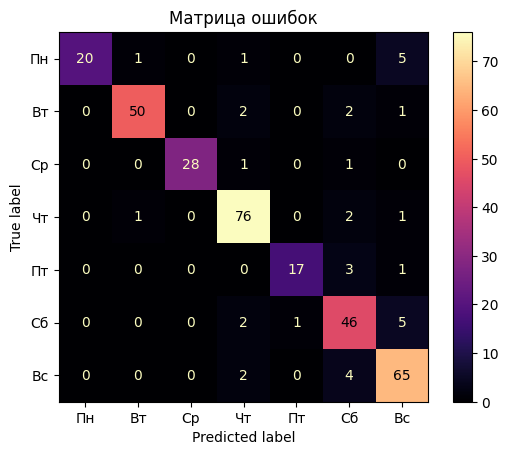

In [32]:
day_names = {
    0: 'Пн',
    1: 'Вт',
    2: 'Ср',
    3: 'Чт', 
    4: 'Пт',
    5: 'Сб',
    6: 'Вс'
}

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(day_names.values()))
disp.plot(cmap='magma')
plt.title('Матрица ошибок')
plt.show()

In [33]:
total_per_class = cm.sum(axis=1)
correct_per_class = np.diag(cm)
errors_per_class = total_per_class - correct_per_class
error_pct = errors_per_class / total_per_class * 100

df_errors = pd.DataFrame({
    'day': [day_names[i] for i in range(7)],
    'total': total_per_class,
    'errors': errors_per_class,
    'error_pct': error_pct
}).sort_values('error_pct', ascending=False)

df_errors

,day,total,errors,error_pct
0,Пн,27,7,25.925926
4,Пт,21,4,19.047619
5,Сб,54,8,14.814815
1,Вт,55,5,9.090909
6,Вс,71,6,8.450704
2,Ср,30,2,6.666667
3,Чт,80,4,5.000000


In [34]:
worst_day = df_errors.iloc[0]['day']
worst_pct = df_errors.iloc[0]['error_pct']
print(f"Хуже всего предсказание для класса: {worst_day} ({worst_pct:.2f}%)")

Хуже всего предсказание для класса: Пн (25.93%)


In [35]:
joblib.dump(best_model, '../data/ex00.pkl')

['../data/ex00.pkl']